In [1]:
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.legend_handler import HandlerLine2D

In [2]:
countries = ["ALB", "BGD", "BOL", "BRN","CYP", "ECU", "ETH", "B35", "GRC", "HUN", "IND", "KEN","KOR",
             "MAR", "MKD", "MNE", "NGA", "NZ1", "PNG", "SAU", "TUR", "TZA", "US1", "VNM"
            ]


In [3]:
def read_data(country):
    #the updated indicator list from Creating_final_fixed_idnicator_csv.ipynb
    df = pd.read_csv(rf"..\data\ouput\country_analysis\v5_indicators\{country}\{country}_all_monthly_metrics_update.csv")
    df["country"] =f"{country}"
    return df

In [4]:
dfs = []

for c in countries:
    df = read_data(c)
    dfs.append(df)

result_all = pd.concat(dfs, ignore_index=True)

In [5]:
result_all["contributors_total_ohsome"] = result_all["contributors_casual_total"] + result_all["contributors_inactive_total"] +result_all["contributors_prolific_total"]

In [6]:
result_all["contributors_inactive_share_total"]= result_all["contributors_inactive_total"]/result_all["contributors_total_ohsome"]
result_all["contributors_prolific_share_total"]= result_all["contributors_prolific_total"]/result_all["contributors_total_ohsome"]
result_all["contributors_casual_share_total"]= result_all["contributors_casual_total"]/result_all["contributors_total_ohsome"]

In [7]:
result_all["contributors_ai_ohsome"] = result_all["contributors_inactive_ai"] + result_all["contributors_prolific_ai"] +result_all["contributors_casual_ai"]

In [8]:
result_all["contributors_inactive_share_ai"]= result_all["contributors_inactive_ai"]/result_all["contributors_ai_ohsome"]
result_all["contributors_prolific_share_ai"]= result_all["contributors_prolific_ai"]/result_all["contributors_ai_ohsome"]
result_all["contributors_casual_share_ai"]= result_all["contributors_casual_ai"]/result_all["contributors_ai_ohsome"]

In [9]:
result_all["test"] = result_all["contributors_inactive_share_ai"] + result_all["contributors_prolific_share_ai"] +result_all["contributors_casual_share_ai"]

In [11]:
test = result_all[["months", "country","contributors_prolific_share_ai", "contributors_casual_share_ai", "contributors_inactive_share_ai",
                  "contributors_inactive_share_total", "contributors_prolific_share_total", "contributors_casual_share_total"]]

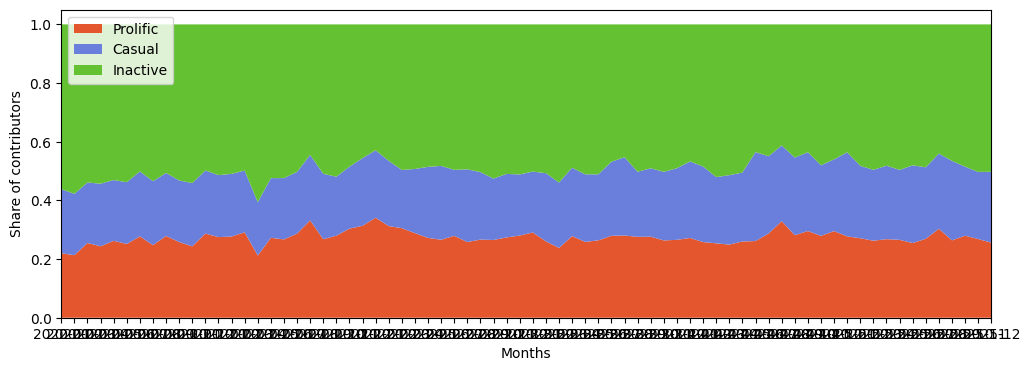

In [13]:

# Aggregate: mean share across all 31 countries, per month
agg = (
    test.groupby("months")[[
        "contributors_casual_share_total",
        "contributors_prolific_share_total",
        "contributors_inactive_share_total"
    ]]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 4))

ax.stackplot(
    agg["months"],
    agg["contributors_prolific_share_total"],
    agg["contributors_casual_share_total"],
    agg["contributors_inactive_share_total"],
    colors=["#E4572E", "#6A7FDB", "#63C132"],
    labels=["Prolific", "Casual", "Inactive"]
)

ax.set_xlabel("Months")
ax.set_ylabel("Share of contributors")
ax.legend(loc="upper left")
ax.set_xlim(agg["months"].min(), agg["months"].max())
plt.show()

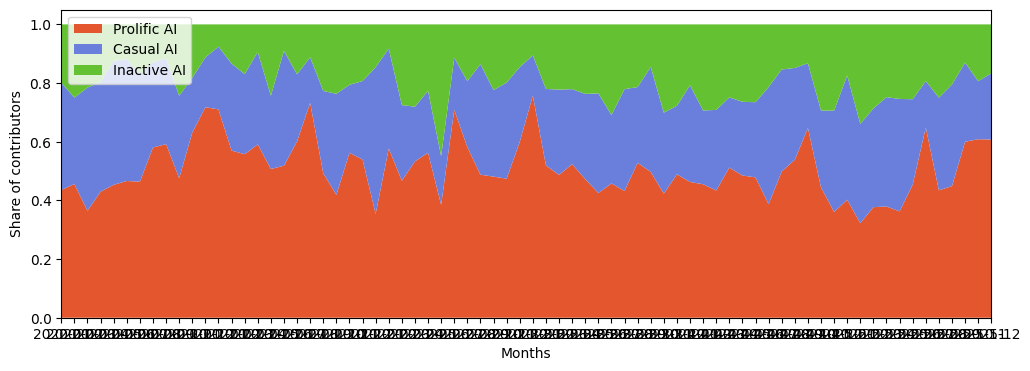

In [106]:

# Aggregate: mean share across all 31 countries, per month
agg = (
    test.groupby("months")[[
        "contributors_prolific_share_ai",
        "contributors_casual_share_ai",
        "contributors_inactive_share_ai"
    ]]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 4))

ax.stackplot(
    agg["months"],
    agg["contributors_prolific_share_ai"],
    agg["contributors_casual_share_ai"],
    agg["contributors_inactive_share_ai"],
    colors=["#E4572E", "#6A7FDB", "#63C132"],
    labels=["Prolific AI", "Casual AI", "Inactive AI"]
)

ax.set_xlabel("Months")
ax.set_ylabel("Share of contributors")
ax.legend(loc="upper left")
ax.set_xlim(agg["months"].min(), agg["months"].max())
plt.show()

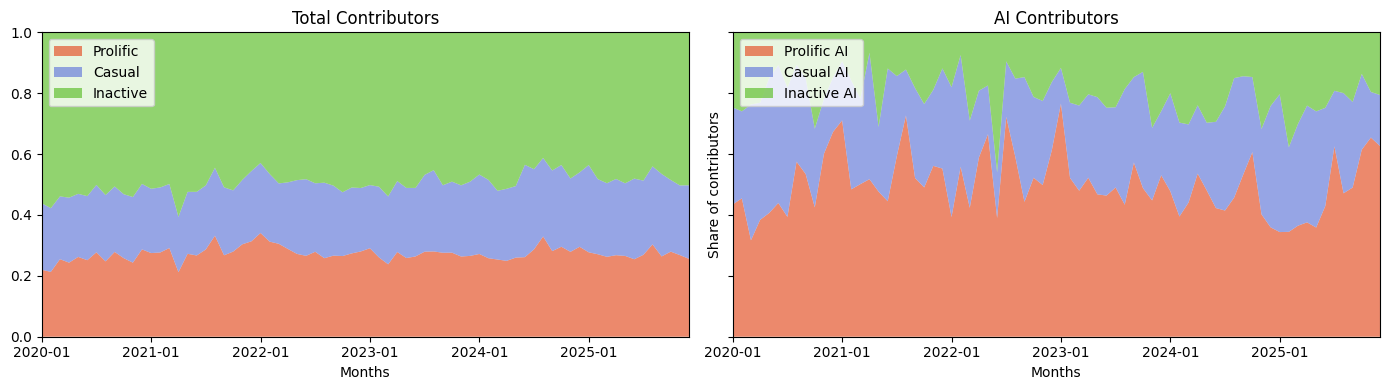

In [15]:
# Aggregate: mean share across all 31 countries, per month (AI shares)
agg_ai = (
    test.groupby("months")[[
        "contributors_prolific_share_ai",
        "contributors_casual_share_ai",
        "contributors_inactive_share_ai"
    ]]
    .mean()
    .reset_index()
)

# Aggregate: mean share across all 31 countries, per month (total shares)
agg_total = (
    test.groupby("months")[[
        "contributors_casual_share_total",
        "contributors_prolific_share_total",
        "contributors_inactive_share_total"
    ]]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].stackplot(
    agg_total["months"],
    agg_total["contributors_prolific_share_total"],
    agg_total["contributors_casual_share_total"],
    agg_total["contributors_inactive_share_total"],
    colors=["#E4572E", "#6A7FDB", "#63C132"],
    labels=["Prolific", "Casual", "Inactive"],
    alpha=0.7
)
axes[0].set_xlabel("Months")
axes[0].set_title("Total Contributors")
axes[0].legend(loc="upper left")
axes[0].set_xlim(agg_total["months"].min(), agg_total["months"].max())
axes[0].set_ylim(0,1)

axes[0].set_xticks(agg_total["months"][::12])


axes[1].stackplot(
    agg_ai["months"],
    agg_ai["contributors_prolific_share_ai"],
    agg_ai["contributors_casual_share_ai"],
    agg_ai["contributors_inactive_share_ai"],
    colors=["#E4572E", "#6A7FDB", "#63C132"],
    labels=["Prolific AI", "Casual AI", "Inactive AI"],
    alpha=0.7
)
axes[1].set_xlabel("Months")
axes[1].set_ylabel("Share of contributors")
axes[1].set_title("AI Contributors")
axes[1].legend(loc="upper left")
axes[1].set_xlim(agg_ai["months"].min(), agg_ai["months"].max())
axes[1].set_xticks(agg_ai["months"][::12])


plt.tight_layout()
plt.savefig("../results/monthly_contribs_skill_level_ohsome_share_top25_v2.png", dpi=300)

plt.show()